![Machine Learning Lab](banner.jpg)


# Laboratorio 5 Actividad


## Instrucciones generales


1. Esta actividad debe ser entregada por BN y es de carácter individual. No se permite entregar el laboratorio después de la fecha establecida.
2. Al responder las preguntas de las actividades por favor marcar las respuestas con la sección a la que corresponden, por ejemplo: `## Exploración de datos 2.1`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor nombrar el archivo de acuerdo al siguiente formato `{email}_lab5.ipynb`.
4. Si tienen alguna duda pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams

### 0\. Descarga del dataset

Utiliza el siguiente enlace para descargar el dataset de Twitter Tweets Sentiment:

[Descargar Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset)

El dataset contiene tweets reales con clasificación de sentimiento en 3 clases (positive/negative/neutral)


### 1\. Exploración de datos (5%)

1. **Carga del dataset**:
   - Cargar el dataset
   - Seleccionar solo las columnas necesarias: `text` y `sentiment`
   - Eliminar filas con valores faltantes

2. **Análisis exploratorio**:
   - Analizar las primeras 10 filas del dataset limpio
   - Mostrar la distribución de clases (Positive, Negative, Neutral)
   - Verificar el tamaño final del dataset


### 2\. Procesamiento de datos (15%)

Los algoritmos de Machine Learninng no trabajan directamente con texto. Por eso debemos convertir palabras en vectores numéricos mediante técnicas como [Bag-of-Words](https://www.ibm.com/think/topics/bag-of-words), un método que cuantifica la frecuencia de palabras en documentos de texto. Esto transforma frases como "muy muy mala pelicula" en vectores como [0, 2, 1, 1, 0, 0, ..., 0] donde cada posición representa una palabra del vocabulario.

Scikit-learn provee una clase [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) que convierte una colección de documentos a una matriz de conteo de palabras. Adicionalmente, realiza procesamiento convirtiendo el texto a minúsculas y eliminando palabras que no aportan valor a la predicción.

1. Divide el dataset en 80/20 con `train_test_split()`, `stratify=sentiment`, y `random_state=42`.
2. Usa CountVectorizer usando `lowercase=True` y `stop_words='english'` e inicializalo con el conjunto de entrenamiento usando `fit_transform`
   
   ```python
   from sklearn.feature_extraction.text import CountVectorizer
   
   # Vectorizador automático
   vectorizer = CountVectorizer(lowercase=True, stop_words='english')
   
   ...
   ```
3. Compara 3 textos originales con el texto procesado por `CountVectorizer`.

### 3\. Entrenamiento de Naïve Bayes (60%)

1. **Entrenamiento de modelos**:
   - Entrena un modelo de [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) (para frecuencias de palabras)
   - Entrena un modelo de [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (para presencia/ausencia de palabras)

2. **Evaluación y métricas**:
   - Reporta **accuracy**, **precision**, **recall**, y **F1-score** de cada modelo

3. **Análisis comparativo**:
   - ¿Qué modelo obtuvo el mejor rendimiento?

### 4\. Predicciones (20%)

1. Realiza 3 predicciones con el mejor modelo sobre nuevos tweets que demuestren como clasifica el modelo el texto para cada una de las clases.

---

# 0. Descarga del dataset

In [1]:
!mkdir datasets/
!curl -L -o datasets/twitter-tweets-sentiment-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/yasserh/twitter-tweets-sentiment-dataset
!unzip datasets/twitter-tweets-sentiment-dataset.zip -d datasets/twitter-tweets-sentiment-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1259k  100 1259k    0     0   903k      0  0:00:01  0:00:01 --:--:-- 8626k
Archive:  datasets/twitter-tweets-sentiment-dataset.zip
  inflating: datasets/twitter-tweets-sentiment-dataset/Tweets.csv  


## 1. Exploración de datos

### 1.1 Carga del dataset

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix

In [28]:
df = pd.read_csv("datasets/twitter-tweets-sentiment-dataset/Tweets.csv")
df = df[["text", "sentiment"]].dropna()

### 1.2 Análisis exploratorio

In [29]:
df.head(10)

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative
5,http://www.dothebouncy.com/smf - some shameles...,neutral
6,2am feedings for the baby are fun when he is a...,positive
7,Soooo high,neutral
8,Both of you,neutral
9,Journey!? Wow... u just became cooler. hehe....,positive


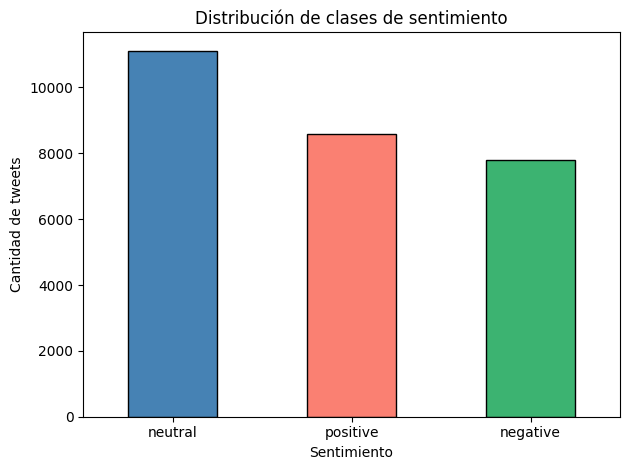

In [30]:
df["sentiment"].value_counts().plot(kind='bar', color=['steelblue', 'salmon', 'mediumseagreen'], edgecolor='black')

plt.title("Distribución de clases de sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 27480, Columnas: 2


## 2. Procesamiento de datos

### 2.1 División del dataset

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["sentiment"], test_size=0.2, stratify=df["sentiment"], random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras \nPrueba: {X_test.shape[0]} muestras")

Entrenamiento: 21984 muestras 
Prueba: 5496 muestras


### 2.2 Vectorización con CountVectorizer

In [33]:
vectorizer = CountVectorizer(lowercase=True, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Vocabulario: {len(vectorizer.vocabulary_)} palabras")
print(f"Matriz de entrenamiento: {X_train_vec.shape}")

Vocabulario: 22678 palabras
Matriz de entrenamiento: (21984, 22678)


### 2.3 Comparación de textos originales vs. procesados

In [34]:
analyzer = vectorizer.build_analyzer()
samples = X_train.iloc[:3]

for text in samples:
    print(f"Original: {text}")
    print(f"Procesado: {analyzer(text)}\n")

Original:  Press `Ctrl` on bottom right. It`s there.  KY
Procesado: ['press', 'ctrl', 'right', 'ky']

Original: ah remember the days when you`d sleep in until noon? well guess who did that today? god i feel like a loser
Procesado: ['ah', 'remember', 'days', 'sleep', 'noon', 'guess', 'did', 'today', 'god', 'feel', 'like', 'loser']

Original: my momma is comin 2night !  2morrow tennis day with p?nar yuppie !
Procesado: ['momma', 'comin', '2night', '2morrow', 'tennis', 'day', 'nar', 'yuppie']



## 3. Entrenamiento de Naïve Bayes

### 3.1 Entrenamiento de modelos

In [35]:
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [36]:
bnb = BernoulliNB()
bnb.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 3.2 Evaluación y métricas

In [37]:
mnb_preds = mnb.predict(X_test_vec)
bnb_preds = bnb.predict(X_test_vec)

print("MultinomialNB\n")
print(f"Exactitud: {accuracy_score(y_test, mnb_preds):.4f}")
print(classification_report(y_test, mnb_preds))

print("")

print("BernoulliNB\n")
print(f"Exactitud: {accuracy_score(y_test, bnb_preds):.4f}")
print(classification_report(y_test, bnb_preds))

MultinomialNB

Exactitud: 0.6437
              precision    recall  f1-score   support

    negative       0.68      0.60      0.64      1556
     neutral       0.59      0.67      0.63      2223
    positive       0.70      0.65      0.68      1717

    accuracy                           0.64      5496
   macro avg       0.66      0.64      0.65      5496
weighted avg       0.65      0.64      0.64      5496


BernoulliNB

Exactitud: 0.6303
              precision    recall  f1-score   support

    negative       0.74      0.43      0.54      1556
     neutral       0.54      0.82      0.66      2223
    positive       0.79      0.57      0.66      1717

    accuracy                           0.63      5496
   macro avg       0.69      0.61      0.62      5496
weighted avg       0.67      0.63      0.62      5496



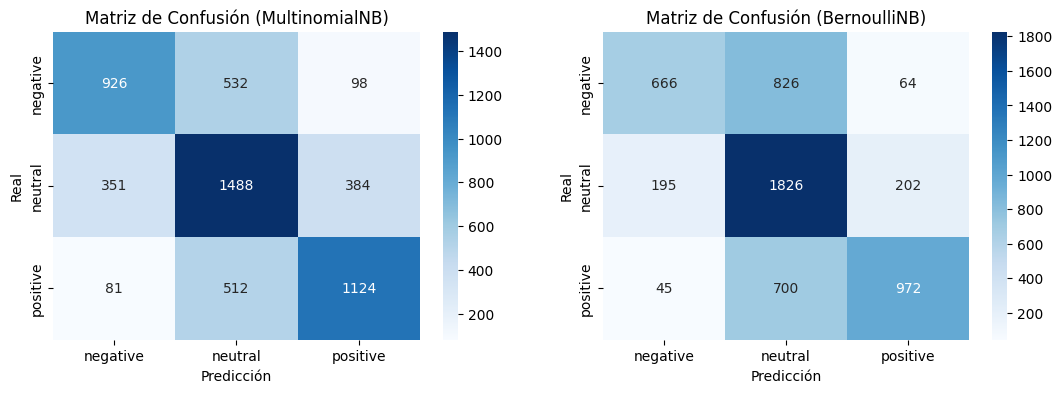

In [ ]:
cm = confusion_matrix(y_test, mnb_preds)
class_names = mnb.classes_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión (MultinomialNB)')

cm = confusion_matrix(y_test, bnb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (BernoulliNB)')

plt.show()


### 3.3 Análisis comparativo

Podemos ver con las métricas entregadas que el modelo de **MultinomialNB obtuvo un mejor rendimiento** que el modelo de BernoulliNB. Esto se debe a que el modelo de MultinomialNB es más adecuado para datos de texto donde la **frecuencia de palabras es importante**, mientras que el modelo de BernoulliNB se enfoca en la **presencia o ausencia de palabras**, lo cual puede no capturar toda la información relevante en este caso.

No obstante, la diferencia entre ambas no fue tan substancial, pienso yo que en este caso de análisis de sentimientos la repetición o no de las palabras no es tan importante, sino más bien la presencia o ausencia de ciertas palabras clave. Por ejemplo, en un tweet como "muy muy mala pelicula" el modelo de MultinomialNB podría interpretar que la palabra "mala" es más relevante debido a su frecuencia, mientras que el modelo de BernoulliNB solo consideraría su presencia sin importar cuántas veces aparezca. En este caso, ambos modelos podrían tener un rendimiento similar, pero el modelo de MultinomialNB podría capturar mejor la intensidad del sentimiento negativo debido a la repetición de la palabra "mala".

## 4. Predicciones

In [44]:
new_tweets = [
    "I absolutely love this! Best day ever, feeling so happy and grateful!", # Este debería dar positivo.
    "This is the worst thing that has ever happened to me. Totally disappointed and angry.", # Este debería dar negativo.
    "The event starts at 9am. Please bring your ID card and registration form.", # Este debería dar neutral.
    "What do you think about the new movie? Maybe you want me to say: \"Omg it's amazing\". No, ridiculous.", # Este debería dar negativo, pero es probable que no lo haga, porque el modelo seguramente no entiende sarcasmo.
]

for tweet in new_tweets:
    vec = vectorizer.transform([tweet])
    prediction = mnb.predict(vec)[0]
    print(f"Tweet: {tweet}")
    print(f"Sentimiento: {prediction}\n")

Tweet: I absolutely love this! Best day ever, feeling so happy and grateful!
Sentimiento: positive

Tweet: This is the worst thing that has ever happened to me. Totally disappointed and angry.
Sentimiento: negative

Tweet: The event starts at 9am. Please bring your ID card and registration form.
Sentimiento: neutral

Tweet: What do you think about the new movie? Maybe you want me to say: "Omg it's amazing". No, ridiculous.
Sentimiento: positive

